In [161]:
from IPython.display import HTML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 50)
sns.set()
%matplotlib inline

In [162]:
path= 'Loan_Default.csv'
data= pd.read_csv(path)
df= data.copy()

## EDA

In [163]:
df.shape

(148670, 34)

In [164]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [165]:
df.dtypes.value_counts()

object     21
float64     8
int64       5
Name: count, dtype: int64

<Figure size 1200x600 with 0 Axes>

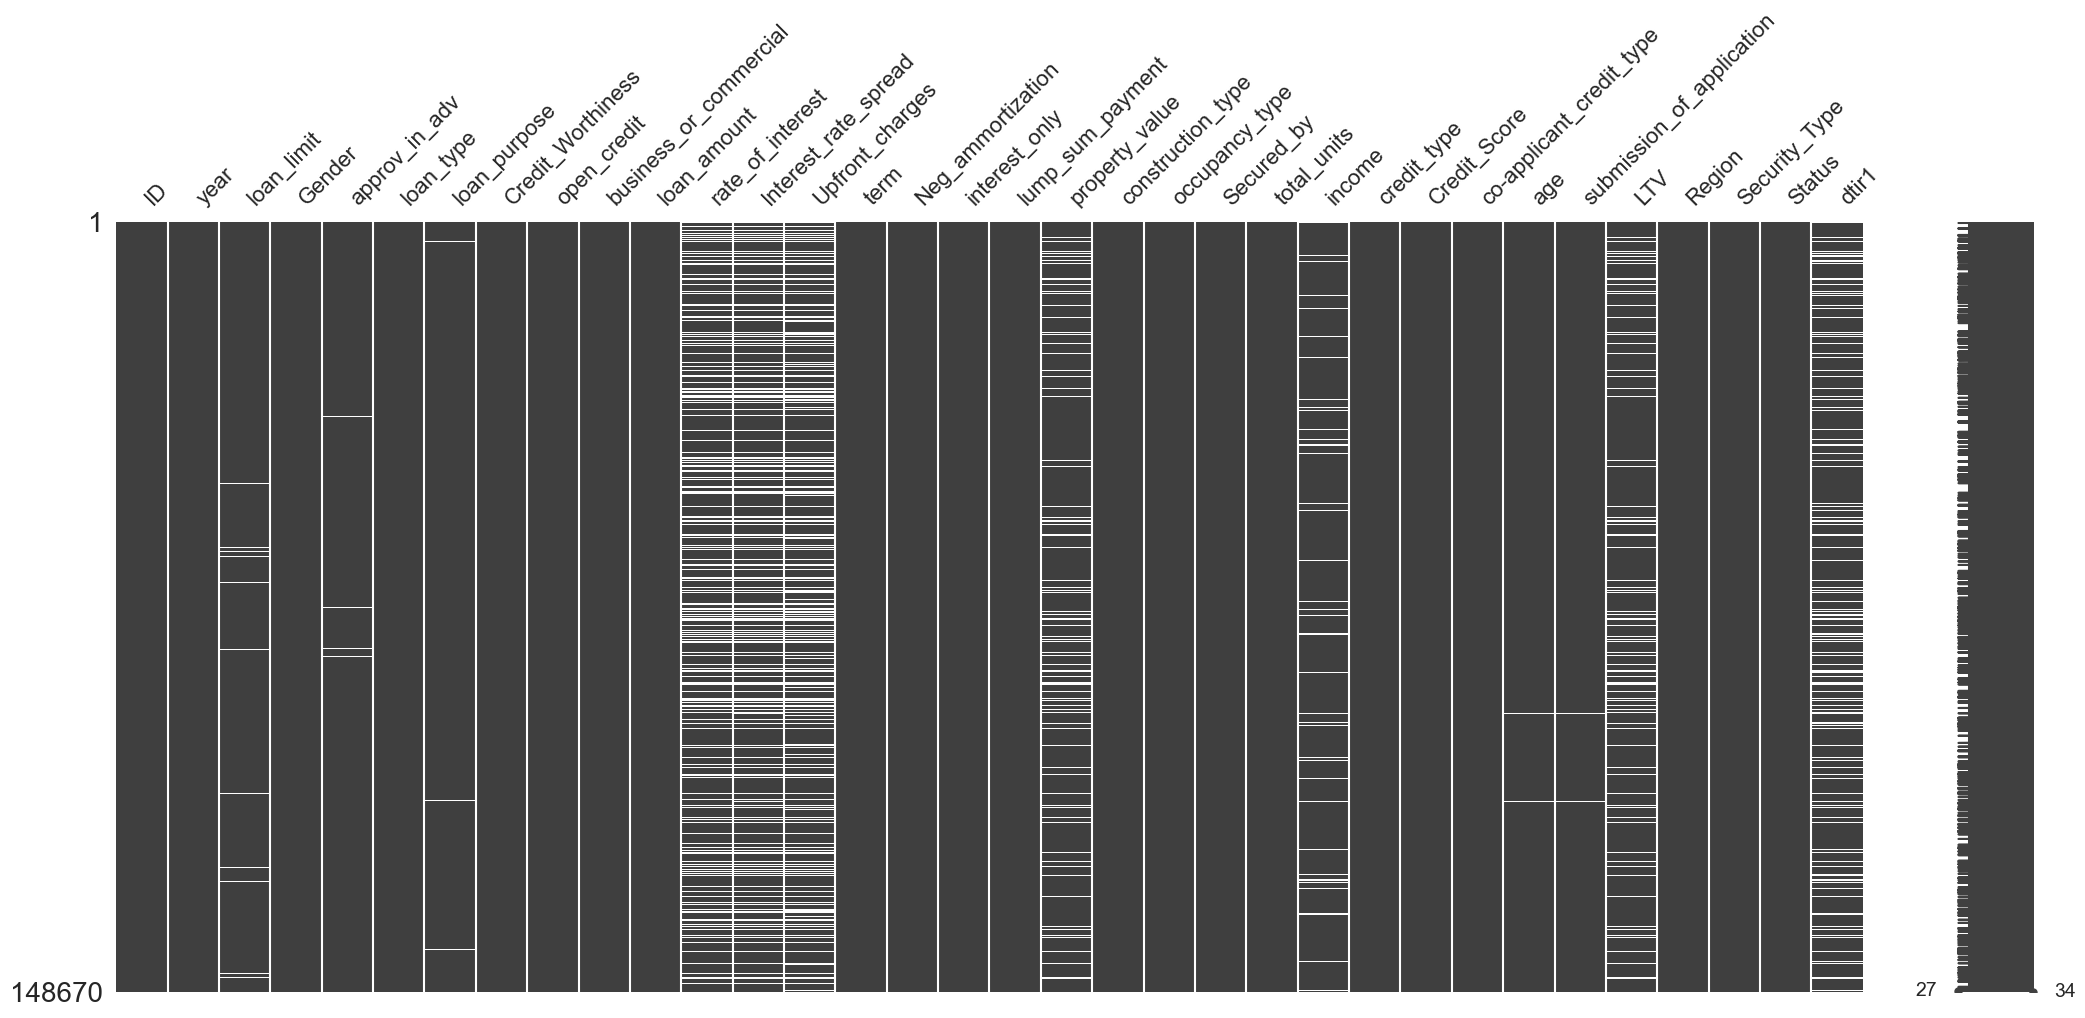

In [166]:
import missingno
plt.figure(figsize= (12, 6))
missingno.matrix(df)
plt.show()

In [167]:
mask= df.isna().sum().sort_values(ascending= False) > 0
df.isna().sum().sort_values(ascending= False)[mask]

Upfront_charges              39642
Interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
LTV                          15098
property_value               15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
Neg_ammortization              121
term                            41
dtype: int64

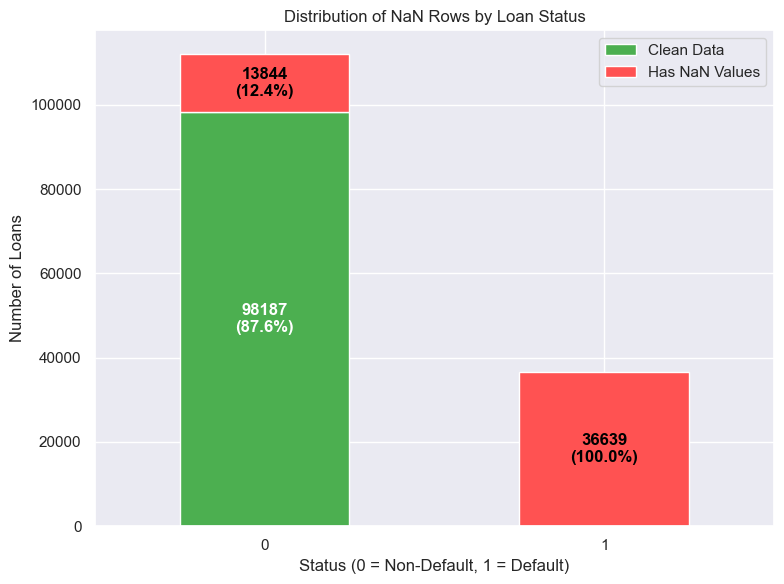

In [168]:
df['has_nan'] = df.isna().any(axis=1)
plot_data = df.groupby(['Status', 'has_nan']).size().unstack(fill_value=0)
totals = plot_data.sum(axis=1)

# 2. Plot Bars
ax = plot_data.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF5252'], figsize=(8, 6))

# 3. Fixed Labeling Logic
for i, status in enumerate(plot_data.index):
    cumulative_height = 0
    for column in plot_data.columns:
        val = plot_data.loc[status, column]
        if val > 0:
            percentage = (val / totals[status]) * 100
            # Position text in the middle of the current segment
            y_pos = cumulative_height + (val / 2)
            
            # Dynamic color for readability (White on green, Black on red)
            text_color = 'white' if column == False else 'black'
            
            ax.text(i, y_pos, f'{val}\n({percentage:.1f}%)', 
                    ha='center', va='center', 
                    color=text_color, fontweight='bold')
        
        cumulative_height += val

plt.title('Distribution of NaN Rows by Loan Status')
plt.xlabel('Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Number of Loans')
plt.legend(['Clean Data', 'Has NaN Values'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fixed_nan_status_plot.png')

**Because the data with nan values all represents those that defaulted, we must clean it to train the model**

**Questions to ask**

In [169]:
# what does the data represents > unknown
# where was the data collected, when, how. > 2019, each row is a unique loan given to some person(x)
# we don't know were it was collected
# is it relevant to use all cols ? > perhaps not, many might be correlated, we'll investigate

In [170]:
# duplicates:
# target y:
# corr:
# pairplots:
# domain knowledge engineer features to check the data is valid (consistent with real-world trends)
# > frequency bars (def/non-def) and pie charts

In [171]:
relevant_cols= ['loan_limit','approv_in_adv','Gender','loan_type','loan_purpose',
                'loan_amount','rate_of_interest','term','Neg_ammortization','lump_sum_payment',
                'occupancy_type','Secured_by','income','Credit_Score','age',
                 'submission_of_application','LTV','Region','Security_Type','dtir1']

In [172]:
flag_identifier= ['Gender','Region','income','Credit_Score','Credit_Worthiness','age']
print('nb of duplicates:',df.duplicated().sum())
print('nb of people taking on multiple loans at once:',
df.duplicated(subset= ['Gender','Region','income','Credit_Score','Credit_Worthiness','age']).sum())

nb of duplicates: 0
nb of people taking on multiple loans at once: 6171


In [173]:
# adding an identifier to flag those who took multiple loans at once.
df['count']= df.groupby(flag_identifier, dropna= False)['ID'].transform('count')

In [174]:
# 1. Get the counts of missing values (your existing logic)
nan_counts = df.isna().sum().sort_values(ascending=False)
mask = nan_counts > 0
nan_series = nan_counts[mask]

# 2. Calculate the Default vs Non-Default percentages for those specific columns
# We iterate only through columns that have NaNs
results = []
for col in nan_series.index:
    # Filter for rows where THIS specific column is NaN
    nan_rows = df[df[col].isna()]
    
    # Calculate percentages of Status
    stats = nan_rows['Status'].value_counts(normalize=True) * 100
    results.append({
        'Column': col,
        'NaN Count': nan_series[col],
        'Non-Default % (0)': stats.get(0, 0),
        'Default % (1)': stats.get(1, 0)
    })

# 3. Display as a single clean table
summary_table = pd.DataFrame(results).set_index('Column')
print(summary_table.round(2))

                           NaN Count  Non-Default % (0)  Default % (1)
Column                                                                
Upfront_charges                39642               7.96          92.04
Interest_rate_spread           36639               0.00         100.00
rate_of_interest               36439               0.00         100.00
dtir1                          24121              32.38          67.62
LTV                            15098               0.01          99.99
property_value                 15098               0.01          99.99
income                          9150              86.46          13.54
loan_limit                      3344              73.65          26.35
approv_in_adv                    908              73.46          26.54
submission_of_application        200               0.00         100.00
age                              200               0.00         100.00
loan_purpose                     134              73.88          26.12
Neg_am

**imputing LTV/property_value**
+ procedure: group loan_amounts into bins
+ check their ltv percentage of property_value
+ impute the pv, and the ltv for missings

In [175]:
from optbinning import OptimalBinning

# 1. Initialize for a specific column
optb = OptimalBinning(name="loan_amount", dtype="numerical", solver="cp")

# 2. Fit the data (automatically handles your missing values)
optb.fit(df["loan_amount"].values, df["Status"].values)

# 3. Get the WoE table and Information Value (IV)
binning_table = optb.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 111500.00)",10030,0.067465,6515,3515,0.350449,-0.500595,0.018914,0.002340
1,"[111500.00, 141500.00)",8396,0.056474,5946,2450,0.291806,-0.231032,0.003187,0.000397
2,"[141500.00, 171500.00)",10075,0.067768,7216,2859,0.283772,-0.191834,0.002613,0.000326
3,"[171500.00, 201500.00)",9825,0.066086,7184,2641,0.268804,-0.116964,0.000931,0.000116
4,"[201500.00, 221500.00)",8259,0.055553,6187,2072,0.250878,-0.023726,0.000031,0.000004
5,"[221500.00, 281500.00)",22198,0.149311,16791,5407,0.243581,0.015486,0.000036,0.000004
6,"[281500.00, 311500.00)",10120,0.068070,7746,2374,0.234585,0.064938,0.000282,0.000035
7,"[311500.00, 341500.00)",8788,0.059111,6786,2002,0.227811,0.103053,0.000611,0.000076
8,"[341500.00, 431500.00)",22742,0.152970,17794,4948,0.217571,0.162215,0.003858,0.000482
9,"[431500.00, 521500.00)",17655,0.118753,13975,3680,0.208440,0.216695,0.005266,0.000657


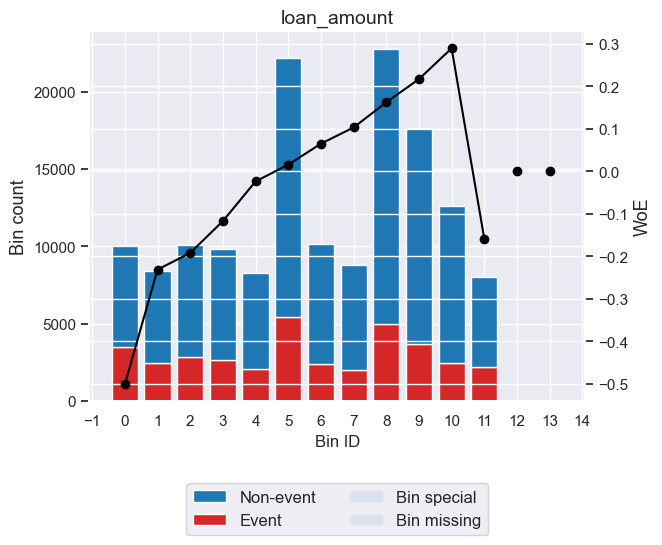

In [176]:
binning_table.plot(metric='woe')
plt.show()

In [177]:
bins = np.concatenate(([-np.inf], optb.splits, [np.inf]))
df['loan_amount_bins']= pd.cut(df['loan_amount'], bins= bins)

In [178]:
df.groupby('loan_amount_bins')[['property_value','LTV']].median()

C:\Users\mmopa\AppData\Local\Temp\ipykernel_13332\276312229.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('loan_amount_bins')[['property_value','LTV']].median()


,property_value,LTV
loan_amount_bins,,
"(-inf, 111500.0]",138000.0,64.204545
"(111500.0, 141500.0]",178000.0,71.067416
"(141500.0, 171500.0]",218000.0,73.989899
"(171500.0, 201500.0]",248000.0,76.162791
"(201500.0, 221500.0]",288000.0,74.280576
"(221500.0, 281500.0]",328000.0,76.580460
"(281500.0, 311500.0]",388000.0,76.417526
"(311500.0, 341500.0]",428000.0,77.573529
"(341500.0, 431500.0]",508000.0,76.433692


In [179]:
#LTV  loan_amunt / property_value * 100
ltv_na= df['LTV'].isna()
print('LTV values that cannot be imputed normally:', df[ltv_na][['loan_amount','property_value']].isna().any(axis= 1).sum())
print('LTV values that can be imputed :', df[ltv_na][['loan_amount','property_value']].notna().all(axis= 1).sum())

LTV values that cannot be imputed normally: 15098
LTV values that can be imputed : 0


In [180]:
df['ltv_median']= df.groupby('loan_amount_bins', dropna= False)['LTV'].transform('median')

C:\Users\mmopa\AppData\Local\Temp\ipykernel_13332\4125649518.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['ltv_median']= df.groupby('loan_amount_bins', dropna= False)['LTV'].transform('median')


In [181]:
def pv_imputer(x):
    return (x['loan_amount'] / x['ltv_median']) *100
df.loc[ltv_na, 'property_value']= df[ltv_na].apply(pv_imputer, axis= 1)
df['LTV']= df['LTV'].fillna((df['loan_amount']/df['property_value'])*100)

In [182]:
df[['LTV','property_value']].isna().sum()

LTV               0
property_value    0
dtype: int64

**Imputing Income Variable**
+ process: using loan_amount bins we find median income of indv
+ for each slice we impute the income accordingly

In [183]:
income_na= df['income'].isna()
df['income_median']= df.groupby('loan_amount_bins', dropna= False)['income'].transform('median')
df.loc[income_na, 'income']= df.loc[income_na, 'income_median']

C:\Users\mmopa\AppData\Local\Temp\ipykernel_13332\554647925.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['income_median']= df.groupby('loan_amount_bins', dropna= False)['income'].transform('median')


**Imputing dtir1**

In [184]:
#dtir1  'loan_amont / income'
dtir_na= df['dtir1'].isna()
print('dtir1 values that cannot be imputed normally:',df[dtir_na][['loan_amount','income']].isna().any(axis= 1).sum())
print('dtir1 values that can be imputed:',df[dtir_na][['loan_amount','income']].notna().all(axis= 1).sum() )

dtir1 values that cannot be imputed normally: 0
dtir1 values that can be imputed: 24121


In [185]:
# starting with normal imputations. loan_amount / income * 100
mask= df[dtir_na][['loan_amount','income']].notna().all(axis= 1)
dtir_na_normalimp= mask[mask].index
df.loc[dtir_na_normalimp, 'dtir1']= (df.loc[dtir_na_normalimp, 'loan_amount'] / df.loc[dtir_na_normalimp, 'income'])*100

**Imputing loan_limit variable**

In [186]:
from IPython.display import display, HTML

# 1. Generate the descriptions
ncf_desc = df[df['loan_limit'] == 'ncf']['loan_amount'].describe().round(2).to_frame(name='NCF')
cf_desc = df[df['loan_limit'] == 'cf']['loan_amount'].describe().round(2).to_frame(name='CF')

# 2. Display as HTML side-by-side
display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>NCF Loan Amounts</h3>{ncf_desc.to_html()}</div>
    <div><h3>CF Loan Amounts</h3>{cf_desc.to_html()}</div>
</div>
"""))

,NCF
count,9978.00
mean,522270.70
std,342595.25
min,36500.00
25%,246500.00
50%,486500.00
75%,726500.00
max,3576500.00
,CF
count,135348.00


In [187]:
loan_limit_na= df['loan_limit'].isna()
max_cf= df[df['loan_limit']== 'ncf']['loan_amount'].max()
def impute_loan_limit(x):
    if x['loan_amount']>max_cf:
        return 'ncf'
    else :
        return 'cf'
df.loc[loan_limit_na, 'loan_limit']= df.loc[loan_limit_na].apply(impute_loan_limit, axis= 1) 

**Imputing approv_in_adv Variable**

In [188]:
# 1. Generate descriptive statistics for 'nopre' and 'pre'
nopre_desc = df[df['approv_in_adv'] == 'nopre']['Credit_Score'].describe().round(2).to_frame(name='No Pre-Approval')
pre_desc = df[df['approv_in_adv'] == 'pre']['Credit_Score'].describe().round(2).to_frame(name='Pre-Approval')


display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>Nopre (No Pre-Approval)</h3>{nopre_desc.to_html()}</div>
    <div><h3>Pre (Pre-Approval)</h3>{pre_desc.to_html()}</div>
</div>
"""))

,No Pre-Approval
count,124621.00
mean,699.84
std,115.87
min,500.00
25%,599.00
50%,699.00
75%,800.00
max,900.00
,Pre-Approval
count,23141.00


In [189]:
# 1. Process 'nopre' group
nopre_stats = df[df['approv_in_adv'] == 'nopre']['Status'].value_counts()
nopre_table = pd.concat([nopre_stats, (nopre_stats/nopre_stats.sum()*100).round(2)], axis=1)
nopre_table.columns = ['Count', 'Percentage (%)']

# 2. Process 'pre' group
pre_stats = df[df['approv_in_adv'] == 'pre']['Status'].value_counts()
pre_table = pd.concat([pre_stats, (pre_stats/pre_stats.sum()*100).round(2)], axis=1)
pre_table.columns = ['Count', 'Percentage (%)']

display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>No Pre-Approval</h3>{nopre_table.to_html()}</div>
    <div><h3>Pre-Approval</h3>{pre_table.to_html()}</div>
</div>
"""))

,Count,Percentage (%)
Status,,
0,93058,74.67
1,31563,25.33
,Count,Percentage (%)
Status,,
0,18306,79.11
1,4835,20.89


In [190]:
df[df['approv_in_adv'].isna()]['Status'].value_counts()

Status
0    667
1    241
Name: count, dtype: int64

In [191]:
# setting the defaulters nan to nopre, the non-defaulters to pre
def impute_aid(x):
    if x['Status']== 0:
        return 'pre'
    else :
        return 'nopre'
df['approv_in_adv']= df.apply(impute_aid, axis= 1)

**Imputing Age**
+ process: creating 25%-75% quantile range around the income for each age group
+ then if our missing person's income lies in some interval impute its age group with the respective one.

In [192]:
# 1. Keep your existing age_stats for the first attempt
age_medians = df.groupby('age')['income'].median()
age_stats = df.groupby('age')['income'].quantile([0.25, 0.75]).unstack()
age_stats.columns = ['q1', 'q3']

# 2. Improved Function: Try Range first, then closest Median
def find_matching_age_fixed(income):
    if pd.isna(income): return None
    
    # Attempt 1: Check if within Q1-Q3 range
    match = age_stats[(income >= age_stats['q1']) & (income <= age_stats['q3'])]
    if not match.empty:
        return match.index[0]
    
    # Attempt 2: If no range match, find the age with the closest median income
    # (income - age_medians).abs() calculates the distance; idxmin() finds the smallest gap
    return (age_medians - income).abs().idxmin()

# 3. Apply to remaining missing values
age_na = df['age'].isna()
df.loc[age_na, 'age'] = df.loc[age_na, 'income'].apply(find_matching_age_fixed)

**Imputing submission_of_application Variable**
+ process: using the common category for each status type

In [193]:
# 1. Process 'to_inst' group
to_inst_stats = df[df['submission_of_application'] == 'to_inst']['Status'].value_counts()
to_inst_table = pd.concat([to_inst_stats, (to_inst_stats/to_inst_stats.sum()*100).round(2)], axis=1)
to_inst_table.columns = ['Count', 'Percentage (%)']

# 2. Process 'not_inst' group
not_inst_stats = df[df['submission_of_application'] == 'not_inst']['Status'].value_counts()
not_inst_table = pd.concat([not_inst_stats, (not_inst_stats/not_inst_stats.sum()*100).round(2)], axis=1)
not_inst_table.columns = ['Count', 'Percentage (%)']

display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>To Institution (to_inst)</h3>{to_inst_table.to_html()}</div>
    <div><h3>Not to Institution (not_inst)</h3>{not_inst_table.to_html()}</div>
</div>
"""))

,Count,Percentage (%)
Status,,
0,68601,71.6
1,27213,28.4
,Count,Percentage (%)
Status,,
0,43430,82.48
1,9226,17.52


In [194]:
# it seems installment based loans are more likely to default
soa_na= df['submission_of_application']
def impute_soa(x):
    if x['Status'] == 0:
        return 'not_inst'
    else :
        return 'to_inst'
df['submission_of_application']= df.apply(impute_soa, axis= 1)

**Imputing loan_purpose Variable**
+ process: using the common category for each status type

In [195]:
purposes = ['p1', 'p2', 'p3', 'p4']
html_blocks = ""

# 2. Loop through categories to create tables
for p in purposes:
    stats = df[df['loan_purpose'] == p]['Status'].value_counts()
    
    # Create combined table (Count + %)
    table = pd.concat([stats, (stats/stats.sum()*100).round(2)], axis=1)
    table.columns = ['Count', 'Percentage (%)']
    
    # Append to HTML string
    html_blocks += f"<div><h3>Purpose: {p}</h3>{table.to_html()}</div>"

# 3. Display all side-by-side
display(HTML(f"""
<div style="display: flex; gap: 30px; flex-wrap: wrap;">
    {html_blocks}
</div>
"""))

,Count,Percentage (%)
Status,,
0,25594,74.12
1,8935,25.88
,Count,Percentage (%)
Status,,
0,2191,66.92
1,1083,33.08
,Count,Percentage (%)
Status,,
0,41938,74.98


In [196]:
lp_na= df['loan_purpose'].isna()
def impute_lp(x):
    if x['Status'] == 0:
        return 'p4' #home investment
    else :
        return 'p3' #debt consolidation -likely to default
df['loan_purpose']= df.apply(impute_lp, axis= 1)

**Impute Neg_ammortization Variable**

In [197]:
# 1. Define the categories
neg_labels = ['not_neg', 'neg_amm']
html_blocks = ""

# 2. Loop through categories to create tables
for label in neg_labels:
    stats = df[df['Neg_ammortization'] == label]['Status'].value_counts()
    
    # Create combined table (Count + %)
    table = pd.concat([stats, (stats/stats.sum()*100).round(2)], axis=1)
    table.columns = ['Count', 'Percentage (%)']
    
    # Append to HTML string
    html_blocks += f"<div><h3>Amortization: {label}</h3>{table.to_html()}</div>"

# 3. Display side-by-side
from IPython.display import display, HTML
display(HTML(f"""
<div style="display: flex; gap: 50px; flex-wrap: wrap;">
    {html_blocks}
</div>
"""))

,Count,Percentage (%)
Status,,
0,103560,77.62
1,29860,22.38
,Count,Percentage (%)
Status,,
0,8382,55.4
1,6747,44.6


In [198]:
neg_amo_na= df['Neg_ammortization'].isna()
def impute_neg_amo(x):
    if x['Status'] == 0:
        return 'neg_amm'
    else :
        return 'not_neg'
df['Neg_ammortization']= df.apply(impute_neg_amo, axis= 1)

**Imputing Term Variable**
+ process: those with missing term we check their income & loan amount, and we act accordingly
+ low income and high loan usually means long term and vice versa.

In [199]:
# 1. Define the Status types
status_types = df['Status'].unique()
html_blocks = ""

# 2. Loop through each Status to describe the 'term' column
for s in sorted(status_types):
    # Calculate descriptive stats for the specific status
    stats = df[df['Status'] == s]['term'].describe().round(2).to_frame(name='Stats')
    
    # Append to HTML string
    html_blocks += f"<div><h3>Status: {s} (Term)</h3>{stats.to_html()}</div>"

# 3. Display side-by-side
from IPython.display import display, HTML
display(HTML(f"""
<div style="display: flex; gap: 50px; flex-wrap: wrap;">
    {html_blocks}
</div>
"""))

,Stats
count,112005.00
mean,335.14
std,58.82
min,96.00
25%,360.00
50%,360.00
75%,360.00
max,360.00
,Stats
count,36624.00


In [200]:
# 1. Calculate the 25th and 75th percentiles for both features per term
stats = df.groupby('term')[['loan_amount', 'income']].quantile([0.25, 0.75]).unstack()

# 2. Function to find a matching term based on interval logic
def find_term_by_interval(row):
    # Iterate through each known term to see if the row fits the 'typical' profile
    for term in stats.index:
        # Check loan_amount interval
        la_q1, la_q3 = stats.loc[term, ('loan_amount', 0.25)], stats.loc[term, ('loan_amount', 0.75)]
        # Check income interval
        inc_q1, inc_q3 = stats.loc[term, ('income', 0.25)], stats.loc[term, ('income', 0.75)]
        
        if (la_q1 <= row['loan_amount'] <= la_q3) and (inc_q1 <= row['income'] <= inc_q3):
            return term
    return None # Return None if no clear match is found

# 3. Identify NaN rows and apply the logic
term_na = df['term'].isna()
df.loc[term_na, 'term'] = df[term_na].apply(find_term_by_interval, axis=1)

# 4. Optional: Fill remaining with the global median if intervals were too strict
df['term'] = df['term'].fillna(df['term'].median())

In [201]:
# 1. Get the counts of missing values (your existing logic)
nan_counts = df.isna().sum().sort_values(ascending=False)
mask = nan_counts > 0
nan_series = nan_counts[mask]

# 2. Calculate the Default vs Non-Default percentages for those specific columns
# We iterate only through columns that have NaNs
results = []
for col in nan_series.index:
    # Filter for rows where THIS specific column is NaN
    nan_rows = df[df[col].isna()]
    
    # Calculate percentages of Status
    stats = nan_rows['Status'].value_counts(normalize=True) * 100
    results.append({
        'Column': col,
        'NaN Count': nan_series[col],
        'Non-Default % (0)': stats.get(0, 0),
        'Default % (1)': stats.get(1, 0)
    })

# 3. Display as a single clean table
summary_table = pd.DataFrame(results).set_index('Column')
print(summary_table.round(2))

                      NaN Count  Non-Default % (0)  Default % (1)
Column                                                           
Upfront_charges           39642               7.96          92.04
Interest_rate_spread      36639               0.00         100.00
rate_of_interest          36439               0.00         100.00


In [202]:
df.head(2)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,has_nan,count,loan_amount_bins,ltv_median,income_median
0,24890,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.000000,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.000000,True,1,"(111500.0, 141500.0]",71.067416,3120.0
1,24891,2019,cf,Male,nopre,type2,p3,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,277999.999998,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,74.280576,North,direct,1,4146.586345,True,1,"(201500.0, 221500.0]",74.280576,4380.0


In [203]:
df['Secured_by'].unique()

array(['home', 'land'], dtype=object)

In [204]:
property_value

NameError: name 'property_value' is not defined

In [ ]:
# treat outliers / handles missings / do transformations
# select cols to keep
# establish pipelines to preprocess
# decide to oversample / class-weight

In [ ]:
# models selection
# hyper establishment / stratified random grid search / learning curves / find best model
# fine tune its hyper space / stratified grid search / test on x_test
# perhaps try validations curves here, and play with other features engineering techniques
# hyper testing using metrics and optimize for one than the other
# include third party to enhance model inference

##### Handling outliers

## Feature Engineering

## Preprocessing

## Model selection

## Model tuning

## Model retraining